In [1]:
import os
import cv2 
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm

torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

C:\Users\jnana\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
CLASS_MAP = {
    "original": (0, -1),
    "deepfakes": (1, 0),
    "faceswap": (1, 1),
    "face2face": (1, 2),
    "neuraltextures": (1, 3),
    "faceshifter": (1, 4),
    "deepfakedetection": (1, 5)
}

NUM_TYPES = 6

In [3]:
class FFPPDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        for class_name in os.listdir(root_dir):
            class_path = os.path.join(root_dir, class_name)

            if class_name not in CLASS_MAP:
                continue

            binary_label, type_label = CLASS_MAP[class_name]

            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                self.samples.append((img_path, binary_label, type_label))

        print(f"Loaded {len(self.samples)} samples from {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, binary_label, type_label = self.samples[idx]

        #image = Image.open(img_path).convert("RGB")
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(binary_label, dtype=torch.float32), torch.tensor(type_label, dtype=torch.long)

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [5]:
train_path = r"C:\Users\jnana\Downloads\deepfake\archive (1)\data\ffpp_multiclass_faces\train"
val_path = r"C:\Users\jnana\Downloads\deepfake\archive (1)\data\ffpp_multiclass_faces\val"

train_dataset = FFPPDataset(train_path, transform=train_transform)
val_dataset = FFPPDataset(val_path, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=0, pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False,
                        num_workers=0, pin_memory=True)

Loaded 98128 samples from C:\Users\jnana\Downloads\deepfake\archive (1)\data\ffpp_multiclass_faces\train
Loaded 26427 samples from C:\Users\jnana\Downloads\deepfake\archive (1)\data\ffpp_multiclass_faces\val


In [6]:
class XceptionMultiTask(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model('xception', pretrained=True)
        in_features = self.backbone.get_classifier().in_features

        self.backbone.reset_classifier(0)

        self.binary_head = nn.Linear(in_features, 1)
        self.type_head = nn.Linear(in_features, NUM_TYPES)

    def forward(self, x):
        features = self.backbone(x)

        binary_out = self.binary_head(features)
        type_out = self.type_head(features)

        return binary_out, type_out


model = XceptionMultiTask().to(device)
#model = model.to(memory_format=torch.channels_last)

C:\Users\jnana\AppData\Local\Programs\Python\Python310\lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


In [7]:
bce_loss = nn.BCEWithLogitsLoss()
ce_loss = nn.CrossEntropyLoss()

def compute_loss(binary_out, type_out, binary_label, type_label):
    
    binary_loss = bce_loss(binary_out.squeeze(), binary_label)

    fake_mask = binary_label == 1

    if fake_mask.sum() > 0:
        type_loss = ce_loss(type_out[fake_mask], type_label[fake_mask])
    else:
        type_loss = 0.0

    return binary_loss + type_loss

In [8]:
optimizer = optim.AdamW(model.parameters(), lr=3e-4)

In [9]:
scaler = torch.cuda.amp.GradScaler()

def train_epoch(loader):
    model.train()
    total_loss = 0

    correct_binary = 0
    total_binary = 0

    correct_type = 0
    total_type = 0

    for images, binary_labels, type_labels in tqdm(loader):
        images = images.to(device)
        binary_labels = binary_labels.to(device)
        type_labels = type_labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            binary_out, type_out = model(images)
            loss = compute_loss(binary_out, type_out, binary_labels, type_labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        # 🔥 Binary Accuracy
        preds_binary = torch.sigmoid(binary_out).squeeze() > 0.5
        correct_binary += (preds_binary == binary_labels).sum().item()
        total_binary += binary_labels.size(0)

        # 🔥 Type Accuracy (only fake samples)
        fake_mask = binary_labels == 1
        if fake_mask.sum() > 0:
            preds_type = torch.argmax(type_out[fake_mask], dim=1)
            correct_type += (preds_type == type_labels[fake_mask]).sum().item()
            total_type += fake_mask.sum().item()

    binary_acc = correct_binary / total_binary
    type_acc = correct_type / total_type if total_type > 0 else 0

    return total_loss / len(loader), binary_acc, type_acc
    
def validate_epoch(loader):
    model.eval()
    total_loss = 0

    correct_binary = 0
    total_binary = 0

    correct_type = 0
    total_type = 0

    with torch.no_grad():
        for images, binary_labels, type_labels in loader:
            images = images.to(device)
            binary_labels = binary_labels.to(device)
            type_labels = type_labels.to(device)

            binary_out, type_out = model(images)
            loss = compute_loss(binary_out, type_out, binary_labels, type_labels)

            total_loss += loss.item()

            # 🔥 Binary Accuracy
            preds_binary = torch.sigmoid(binary_out).squeeze() > 0.5
            correct_binary += (preds_binary == binary_labels).sum().item()
            total_binary += binary_labels.size(0)

            # 🔥 Type Accuracy
            fake_mask = binary_labels == 1
            if fake_mask.sum() > 0:
                preds_type = torch.argmax(type_out[fake_mask], dim=1)
                correct_type += (preds_type == type_labels[fake_mask]).sum().item()
                total_type += fake_mask.sum().item()

    binary_acc = correct_binary / total_binary
    type_acc = correct_type / total_type if total_type > 0 else 0

    return total_loss / len(loader), binary_acc, type_acc

C:\Users\jnana\AppData\Local\Temp\ipykernel_24044\2159016725.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [10]:
EPOCHS = 80

best_loss = float('inf')
patience = 3
counter = 0

for epoch in range(EPOCHS):
    train_loss, train_bin_acc, train_type_acc = train_epoch(train_loader)
    val_loss, val_bin_acc, val_type_acc = validate_epoch(val_loader)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Bin Acc: {train_bin_acc:.4f} | Type Acc: {train_type_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Bin Acc: {val_bin_acc:.4f} | Type Acc: {val_type_acc:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model_multi.pth")
        torch.save(model, "full_model_multi.pth")
        print(" Model improved, saved.")
    else:
        counter += 1
        print(f" No improvement ({counter}/{patience})")

    if counter >= patience:
        print(" Early stopping triggered!")
        break

  0%|                                                                                         | 0/1534 [00:00<?, ?it/s]C:\Users\jnana\AppData\Local\Temp\ipykernel_24044\2159016725.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████████████████████████████████████████████████████████████████████████| 1534/1534 [23:39<00:00,  1.08it/s]



Epoch 1
Train Loss: 0.2192 | Bin Acc: 0.9541 | Type Acc: 0.9647
Val Loss:   0.1496 | Bin Acc: 0.9586 | Type Acc: 0.9807
 Model improved, saved.


100%|██████████████████████████████████████████████████████████████████████████████| 1534/1534 [22:42<00:00,  1.13it/s]



Epoch 2
Train Loss: 0.0919 | Bin Acc: 0.9770 | Type Acc: 0.9885
Val Loss:   0.1881 | Bin Acc: 0.9508 | Type Acc: 0.9770
 No improvement (1/3)


100%|██████████████████████████████████████████████████████████████████████████████| 1534/1534 [23:04<00:00,  1.11it/s]



Epoch 3
Train Loss: 0.0700 | Bin Acc: 0.9826 | Type Acc: 0.9911
Val Loss:   0.1980 | Bin Acc: 0.9514 | Type Acc: 0.9748
 No improvement (2/3)


100%|██████████████████████████████████████████████████████████████████████████████| 1534/1534 [23:24<00:00,  1.09it/s]



Epoch 4
Train Loss: 0.0553 | Bin Acc: 0.9865 | Type Acc: 0.9924
Val Loss:   0.1613 | Bin Acc: 0.9565 | Type Acc: 0.9826
 No improvement (3/3)
 Early stopping triggered!


In [11]:
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
target_layer = model.backbone.conv4  # IMPORTANT CHANGE
class BinaryWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        binary_out, _ = self.model(x)
        return binary_out


wrapped_model = BinaryWrapper(model)
cam = GradCAMPlusPlus(model=wrapped_model, target_layers=[target_layer])


In [12]:
TYPE_LABELS = ["deepfakes","faceswap","face2face",
               "neuraltextures","faceshifter","deepfakedetection"]

def predict_image(image_path):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    img_np = np.array(image)/255.0

    input_tensor = val_transform(image).unsqueeze(0).to(device)

    binary_out, type_out = model(input_tensor)

    binary_prob = torch.sigmoid(binary_out).item()
    is_fake = binary_prob > 0.5

    if is_fake:
        targets = [ClassifierOutputTarget(0)]
        type_pred = torch.argmax(type_out).item()
        fake_type = TYPE_LABELS[type_pred]
    else:
        targets = [ClassifierOutputTarget(0)]
        fake_type = "Real"
    grayscale_cam = cam(input_tensor=input_tensor,targets=targets,aug_smooth=True,eigen_smooth=True)[0]
    cam_img = np.maximum(grayscale_cam, 0)
    cam_img = cam_img / (cam_img.max() + 1e-8)

    visualization = show_cam_on_image(img_np, cam_img, use_rgb=True)
    

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(visualization)
    plt.title(f"{'Fake' if is_fake else 'Real'} | {fake_type}")

    plt.show()

    print("Fake Probability:", binary_prob)
    print("Prediction:", "Fake" if is_fake else "Real")
    print("Type:", fake_type)

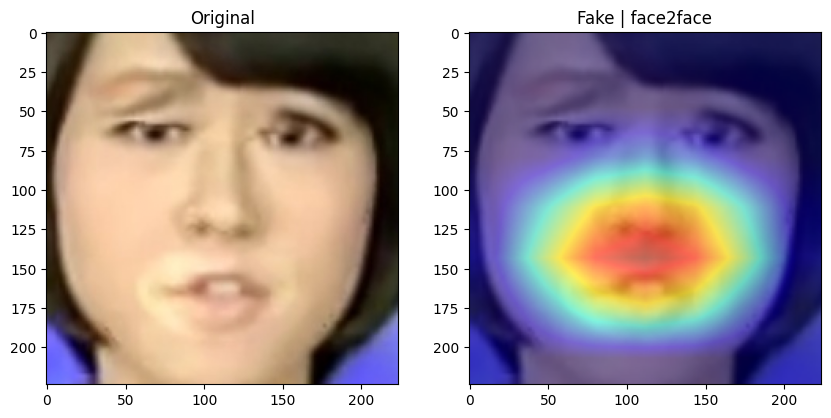

Fake Probability: 0.9999998807907104
Prediction: Fake
Type: face2face


In [13]:
predict_image(r"C:\Users\jnana\Downloads\cgheckingg\611_760_9.jpg")

In [14]:
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
target_layer = model.backbone.conv4  # IMPORTANT CHANGE
class BinaryWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        binary_out, _ = self.model(x)
        return binary_out


wrapped_model = BinaryWrapper(model)
cam = GradCAMPlusPlus(model=wrapped_model, target_layers=[target_layer])


In [15]:
TYPE_LABELS = ["deepfakes","faceswap","face2face",
               "neuraltextures","faceshifter","deepfakedetection"]

def predict_image(image_path):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    img_np = np.array(image)/255.0

    input_tensor = val_transform(image).unsqueeze(0).to(device)

    binary_out, type_out = model(input_tensor)

    binary_prob = torch.sigmoid(binary_out).item()
    is_fake = binary_prob > 0.5

    if is_fake:
        targets = [ClassifierOutputTarget(0)]
        type_pred = torch.argmax(type_out).item()
        fake_type = TYPE_LABELS[type_pred]
    else:
        targets = [ClassifierOutputTarget(0)]
        fake_type = "Real"
    grayscale_cam = cam(input_tensor=input_tensor,targets=targets,aug_smooth=True,eigen_smooth=True)[0]
    cam_img = np.maximum(grayscale_cam, 0)
    cam_img = cam_img / (cam_img.max() + 1e-8)

    visualization = show_cam_on_image(img_np, cam_img, use_rgb=True)
    

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(visualization)
    plt.title(f"{'Fake' if is_fake else 'Real'} | {fake_type}")

    plt.show()

    print("Fake Probability:", binary_prob)
    print("Prediction:", "Fake" if is_fake else "Real")
    print("Type:", fake_type)

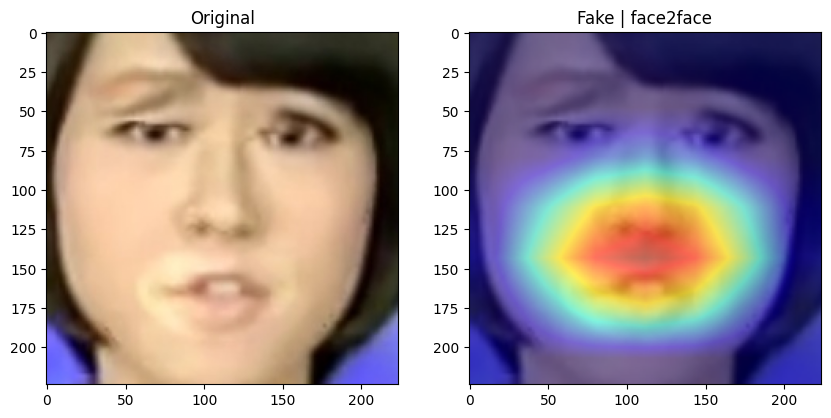

Fake Probability: 0.9999998807907104
Prediction: Fake
Type: face2face


In [16]:
predict_image(r"C:\Users\jnana\Downloads\cgheckingg\611_760_9.jpg")

In [17]:
import cv2
import torch
import numpy as np
from PIL import Image

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load("full_model_multi.pth", map_location=device)
model = model.to(device)
model = model.to(memory_format=torch.channels_last)
model.eval()

C:\Users\jnana\AppData\Local\Temp\ipykernel_24044\1246621155.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("full_model_multi.pth", map_location=devi

XceptionMultiTask(
  (backbone): Xception(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act2): ReLU(inplace=True)
    (block1): Block(
      (skip): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (skipbn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (rep): Sequential(
        (0): SeparableConv2d(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
          (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        )
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReL

In [25]:
import torch.nn as nn

class BinaryWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        binary_out, _ = self.model(x)
        return binary_out

In [26]:
wrapped_model = BinaryWrapper(model)

target_layer = model.backbone.conv4

cam = GradCAMPlusPlus(
    model=wrapped_model,
    target_layers=[target_layer]
)

In [27]:
TYPE_LABELS = [
    "deepfakes",
    "faceswap",
    "face2face",
    "neuraltextures",
    "faceshifter",
    "deepfakedetection"
]

In [28]:
def process_frame(frame):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(rgb)

    input_tensor = val_transform(pil_image).unsqueeze(0).to(
        device, memory_format=torch.channels_last
    )

    with torch.no_grad():
        binary_out, type_out = model(input_tensor)

    binary_prob = torch.sigmoid(binary_out).item()
    is_fake = binary_prob > 0.5

    if is_fake:
        type_pred = torch.argmax(type_out).item()
        fake_type = TYPE_LABELS[type_pred]
    else:
        fake_type = "Real"
        type_pred = 0

    # ---- Grad-CAM target ----
    # Basic (binary):
    # targets = [ClassifierOutputTarget(0)]

    # Better (fake-type based):
    if is_fake:
        targets = [ClassifierOutputTarget(0)]
    else:
        targets = [ClassifierOutputTarget(0)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    # Resize heatmap to frame
    h, w, _ = frame.shape
    cam_resized = cv2.resize(grayscale_cam, (w, h))

    # Heatmap overlay
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_resized),
        cv2.COLORMAP_JET
    )

    overlay = cv2.addWeighted(frame, 0.6, heatmap, 0.4, 0)

    # Text
    label = "FAKE" if is_fake else "REAL"
    text = f"{label} | {fake_type} | {binary_prob:.2f}"

    cv2.putText(
        overlay,
        text,
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (0, 0, 255) if is_fake else (0, 255, 0),
        2
    )

    return overlay

In [29]:
def process_video(input_path, output_path, frame_skip=5):
    cap = cv2.VideoCapture(input_path)

    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % frame_skip == 0:
            processed = process_frame(frame)
        else:
            processed = frame

        out.write(processed)
        frame_count += 1

    cap.release()
    out.release()

    print("Saved to:", output_path)

In [30]:
process_video(
    input_path=r"C:\Users\jnana\Downloads\cgheckingg\618_629.mp4",
    output_path=r"C:\Users\jnana\Downloads\cgheckingg\output_with_heatmap_new.mp4",
    frame_skip=5
)

Saved to: C:\Users\jnana\Downloads\cgheckingg\output_with_heatmap_new.mp4


In [31]:
def process_frame(frame):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(rgb)

    input_tensor = val_transform(pil_image).unsqueeze(0).to(
        device, memory_format=torch.channels_last
    )

    with torch.no_grad():
        binary_out, type_out = model(input_tensor)

    binary_prob = torch.sigmoid(binary_out).item()
    is_fake = binary_prob > 0.5

    if is_fake:
        type_pred = torch.argmax(type_out).item()
        fake_type = TYPE_LABELS[type_pred]
    else:
        fake_type = "Real"
        type_pred = 0

    # ---- Grad-CAM target ----
    if is_fake:
        targets = [ClassifierOutputTarget(type_pred)]
    else:
        targets = [ClassifierOutputTarget(0)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    # ---- Convert CAM to bounding boxes ----
    h, w, _ = frame.shape
    cam_resized = cv2.resize(grayscale_cam, (w, h))

    # Normalize
    cam_resized = np.maximum(cam_resized, 0)
    cam_resized = cam_resized / (cam_resized.max() + 1e-8)

    # Threshold to create mask
    threshold = 0.5
    mask = (cam_resized > threshold).astype(np.uint8)

    # Find contours
    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    # Draw bounding boxes
    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)

        # Filter small noise regions
        if bw * bh < 500:
            continue

        cv2.rectangle(
            frame,
            (x, y),
            (x + bw, y + bh),
            (0, 0, 255),
            2
        )

    # ---- Text ----
    label = "FAKE" if is_fake else "REAL"
    text = f"{label} | {fake_type} | {binary_prob:.2f}"

    cv2.putText(
        frame,
        text,
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (0, 0, 255) if is_fake else (0, 255, 0),
        2
    )

    return frame